In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix
import subprocess
import random
import shutil

In [2]:
import shutil

# Define paths
input_dir = "/kaggle/input/vegetable-image-dataset"
output_dir = "/kaggle/working/vegetable-image-dataset"

# Copy dataset to working directory
shutil.copytree(input_dir, output_dir)

print(f"Dataset copied to {output_dir}")



Dataset copied to /kaggle/working/vegetable-image-dataset


In [3]:
#  dataset root folder
DATASET_DIR = "/kaggle/working/vegetable-image-dataset/Vegetable Images"
TRAIN_DIR = "/kaggle/working/vegetable-image-dataset/Vegetable Images/train"
VAL_DIR = "/kaggle/working/vegetable-image-dataset/Vegetable Images/validation"
TEST_DIR = "/kaggle/working/vegetable-image-dataset/Vegetable Images/test"

#  target image size
IMG_HEIGHT, IMG_WIDTH = 224, 224

# List of class names
CLASSES = ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 
           'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 
           'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']

In [4]:
import cv2
import os
import numpy as np
from PIL import Image

def is_blurry(image_path, threshold=100):
    """
    Check if an image is blurry using Laplacian variance.
    :param image_path: Path to the image file.
    :param threshold: Variance threshold (lower values indicate blurrier images).
    :return: True if the image is blurry, False otherwise.
    """
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read image in grayscale
    if image is None:
        print(f"Warning: Unable to read image {image_path}. Skipping.")
        return True  # Consider unreadable images as blurry to remove them

    laplacian_var = cv2.Laplacian(image, cv2.CV_64F).var()  # Compute Laplacian variance
    return laplacian_var < threshold

def remove_blurry_images(dataset_dir, threshold=100):
    """
    Remove blurry images from a dataset directory.
    :param dataset_dir: Path to the dataset directory.
    :param threshold: Laplacian variance threshold.
    """
    nb=0
    for root, _, files in os.walk(dataset_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                image_path = os.path.join(root, file)
                if is_blurry(image_path, threshold):
                    nb=nb+1
                    #print(f"Removing blurry image: {image_path}")
                    os.remove(image_path)
    print(nb)

# Example usage
dataset_dir = "/kaggle/working/vegetable-image-dataset"
remove_blurry_images(dataset_dir, threshold=100)  # Adjust threshold as needed

1337


In [5]:
def filter_by_resolution(dataset_dir, min_width=224, min_height=224):
    """
    Filter images by resolution and remove those that don't meet the minimum requirements.
    :param dataset_dir: Path to the dataset directory.
    :param min_width: Minimum allowed width.
    :param min_height: Minimum allowed height.
    """
    for root, _, files in os.walk(dataset_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                image_path = os.path.join(root, file)
                try:
                    with Image.open(image_path) as img:
                        width, height = img.size
                        if width != min_width or height != min_height:
                            print(f"Removing image with incorrect resolution: {image_path} ({width}x{height})")
                            os.remove(image_path)
                except Exception as e:
                    print(f"Error processing {image_path}: {e}")

# Example usage
filter_by_resolution(dataset_dir, min_width=224, min_height=224)  # Adjust resolution as needed

Removing image with incorrect resolution: /kaggle/working/vegetable-image-dataset/Vegetable Images/train/Papaya/0126.jpg (224x211)
Removing image with incorrect resolution: /kaggle/working/vegetable-image-dataset/Vegetable Images/train/Papaya/0176.jpg (224x198)
Removing image with incorrect resolution: /kaggle/working/vegetable-image-dataset/Vegetable Images/train/Bitter_Gourd/0609.jpg (224x200)
Removing image with incorrect resolution: /kaggle/working/vegetable-image-dataset/Vegetable Images/train/Bitter_Gourd/0430.jpg (224x193)
Removing image with incorrect resolution: /kaggle/working/vegetable-image-dataset/Vegetable Images/train/Bitter_Gourd/0526.jpg (224x205)
Removing image with incorrect resolution: /kaggle/working/vegetable-image-dataset/Vegetable Images/validation/Papaya/1138.jpg (224x187)
Removing image with incorrect resolution: /kaggle/working/vegetable-image-dataset/Vegetable Images/validation/Papaya/1150.jpg (224x223)
Removing image with incorrect resolution: /kaggle/worki

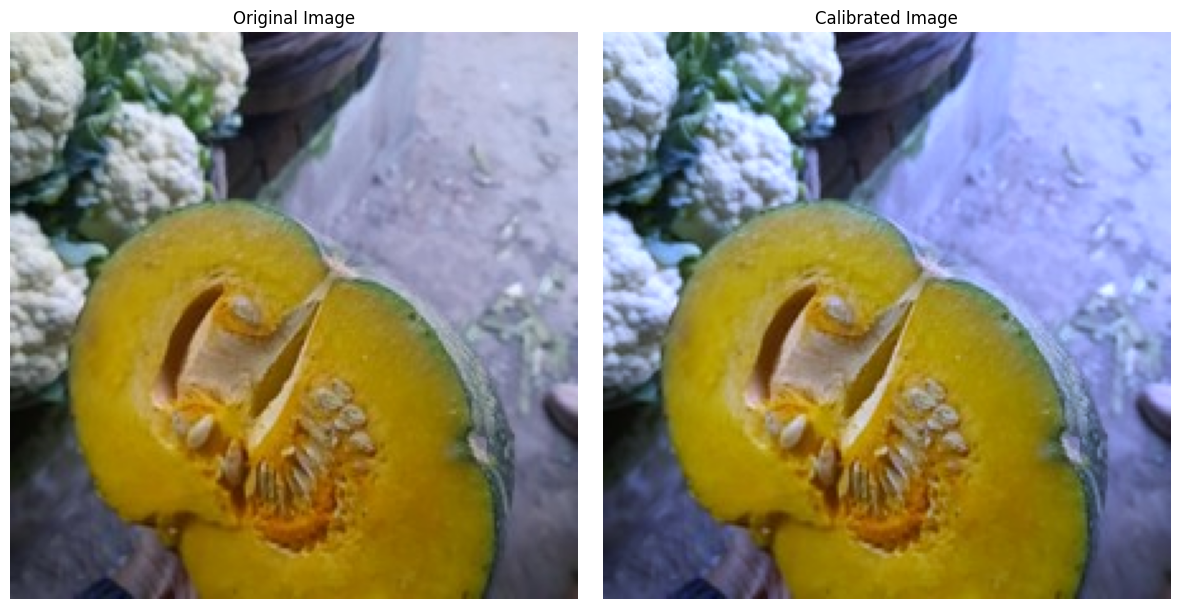

✅ Color calibration completed in place!


In [6]:
def improved_color_calibration(image, roi, target_white=(240, 240, 240), gain_limit=(0.7, 1.3)):
    """
    Performs white balance correction based on a white reference patch.
    
    Parameters:
      image        : Input image (BGR format)
      roi          : Region-of-interest (x, y, w, h) containing the white patch.
      target_white : Desired white point (B, G, R)
      gain_limit   : Allowed range for channel gains (min, max)
      
    Returns:
      calibrated   : Color-corrected image (BGR, uint8)
    """
    x, y, w, h = roi
    patch = image[y:y+h, x:x+w]
    avg_bgr = np.mean(patch, axis=(0, 1))
    avg_rgb = avg_bgr[::-1]  # Convert to RGB order
    target_rgb = np.array(target_white[::-1], dtype=np.float32)
    epsilon = 1e-6
    scales = target_rgb / (avg_rgb + epsilon)
    min_scale = np.min(scales)
    scales = scales / min_scale
    scales = np.clip(scales, gain_limit[0], gain_limit[1])
    scales_bgr = scales[::-1]
    calibrated = image.astype(np.float32)
    calibrated[..., 0] *= scales_bgr[0]
    calibrated[..., 1] *= scales_bgr[1]
    calibrated[..., 2] *= scales_bgr[2]
    calibrated = np.clip(calibrated, 0, 255).astype(np.uint8)
    return calibrated

# Define ROI for your ColorChecker Passport white patch (adjust as needed)
roi = (50, 50, 50, 50)

# Demonstrate on a random image from any dataset folder
classes_all = sorted(set(os.listdir(TRAIN_DIR) + os.listdir(VAL_DIR) + os.listdir(TEST_DIR)))
example_class = random.choice(classes_all)
example_dir = random.choice([TRAIN_DIR, VAL_DIR, TEST_DIR])
example_class_path = os.path.join(example_dir, example_class)
example_images = sorted(os.listdir(example_class_path))
example_img_path = os.path.join(example_class_path, example_images[0])

original_img = cv2.imread(example_img_path)
if original_img is not None:
    calibrated_img = improved_color_calibration(original_img, roi, target_white=(240,240,240), gain_limit=(0.7,1.3))
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(calibrated_img, cv2.COLOR_BGR2RGB))
    plt.title("Calibrated Image")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Error: Could not load example image for calibration demonstration.")

# Process all images in place with color calibration
for dataset_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for class_name in CLASSES:
        class_dir = os.path.join(dataset_dir, class_name)
        for file in os.listdir(class_dir):
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                file_path = os.path.join(class_dir, file)
                image = cv2.imread(file_path)
                if image is None:
                    print("Warning: Could not read", file_path)
                    continue
                calibrated = improved_color_calibration(image, roi, target_white=(220,220,220), gain_limit=(0.8,1.2))
                cv2.imwrite(file_path, calibrated)
print("✅ Color calibration completed in place!")

In [7]:
dataset_path ="/kaggle/working/vegetable-image-dataset/Vegetable Images"
# Class Names
root_path = '/kaggle/working/vegetable-image-dataset/Vegetable Images/train/'
class_names = sorted(os.listdir(root_path))
n_classes = len(class_names)

# Class Distribution
class_dis = [len(os.listdir(root_path + name)) for name in class_names]


# Show
print(f"Total Number of Classes : {n_classes} \nClass Names : {class_names}")

Total Number of Classes : 15 
Class Names : ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


In [9]:
# Data Visualization
import plotly.express as px
import matplotlib.pyplot as plt
# Visualize 
fig = px.pie(names=class_names, values=class_dis, title="Class Distribution", hole=0.4)
fig.update_layout({'title':{'x':0.5}})
fig.show()


In [10]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    shuffle=False
)
# Prepare training dataset from the train directory (after offline augmentation)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    shuffle=True,
    seed=42
)

Found 2836 files belonging to 15 classes.
Found 2814 files belonging to 15 classes.
Found 14005 files belonging to 15 classes.


In [11]:
# Rescale the datasets
rescale_layer = tf.keras.layers.Rescaling(scale=1.0/255)

train_ds = train_ds.map(lambda x, y: (rescale_layer(x), y))
val_ds = val_ds.map(lambda x, y: (rescale_layer(x), y))
test_ds = test_ds.map(lambda x, y: (rescale_layer(x), y))

In [12]:
for images, labels in train_ds.take(1):  # Take one batch of data
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())

Min pixel value: 0.0
Max pixel value: 1.0


In [13]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models, callbacks

# Define augmentation layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),  # Use tf.keras.layers
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.4),
])

# Apply augmentation to the dataset
augmented_dataset = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Batch, shuffle, and prefetch
augmented_dataset = augmented_dataset.batch(32).shuffle(1000).prefetch(tf.data.AUTOTUNE)


# Build a CNN using ResNet50V2 with transfer learning
base_model = ResNet50V2(include_top=False, weights='imagenet', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
base_model.trainable = False  # Freeze base model initially

inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = data_augmentation(inputs)  # Add augmentation layers here
x = base_model(inputs, training=False)
x = layers.Conv2D(32, (3, 3), activation='relu')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(CLASSES), activation='softmax')(x)
model = models.Model(inputs, outputs)
model.summary()

# Set up callbacks
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = callbacks.ModelCheckpoint("/kaggle/working/Image_calssify.keras", monitor='val_loss', save_best_only=True)
tensorboard_cb = callbacks.TensorBoard(log_dir='./logs')

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])



94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 5, 5, 32)            │         589,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │           7,695 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,179,247 (92.24 MB)

 Trainable params: 614,447 (2.34 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [14]:

EPOCHS = 5
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, tensorboard_cb]
)

Epoch 1/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 66s 116ms/step - accuracy: 0.7184 - loss: 0.9599 - val_accuracy: 0.9965 - val_loss: 0.0255
Epoch 2/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 37s 84ms/step - accuracy: 0.9872 - loss: 0.0525 - val_accuracy: 0.9958 - val_loss: 0.0161
Epoch 3/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - accuracy: 0.9954 - loss: 0.0184 - val_accuracy: 0.9972 - val_loss: 0.0109
Epoch 4/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.9977 - loss: 0.0102 - val_accuracy: 0.9989 - val_loss: 0.0086
Epoch 5/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.9979 - loss: 0.0062 - val_accuracy: 0.9975 - val_loss: 0.0097


In [15]:
# Evaluate on validation and test sets
val_loss, val_accuracy = model.evaluate(val_ds)
print("Validation Accuracy: {:.3f}".format(val_accuracy))
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Accuracy: {:.3f}".format(test_accuracy))

89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9990 - loss: 0.0097
Validation Accuracy: 0.999
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.9958 - loss: 0.0175
Test Accuracy: 0.997


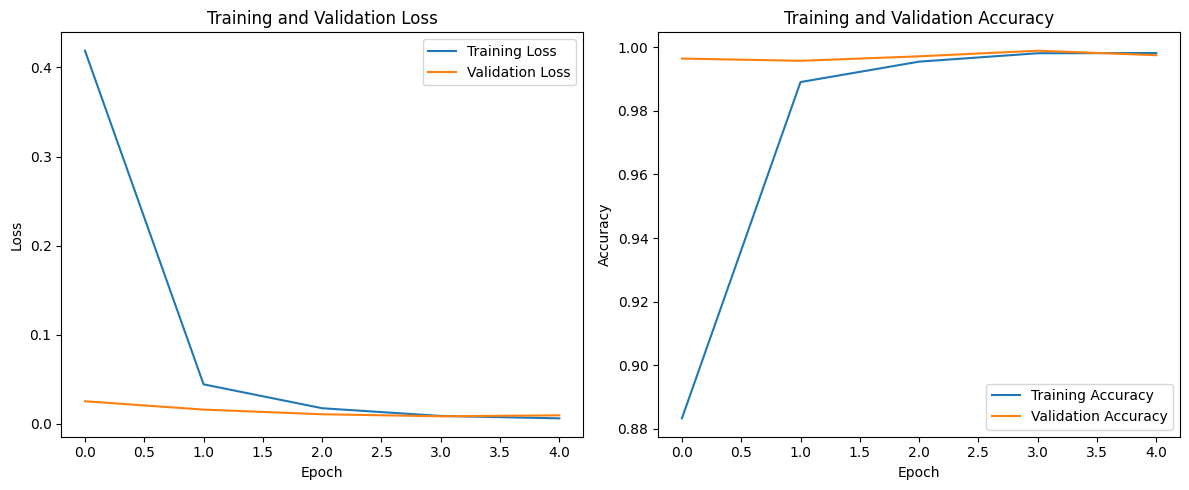

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━

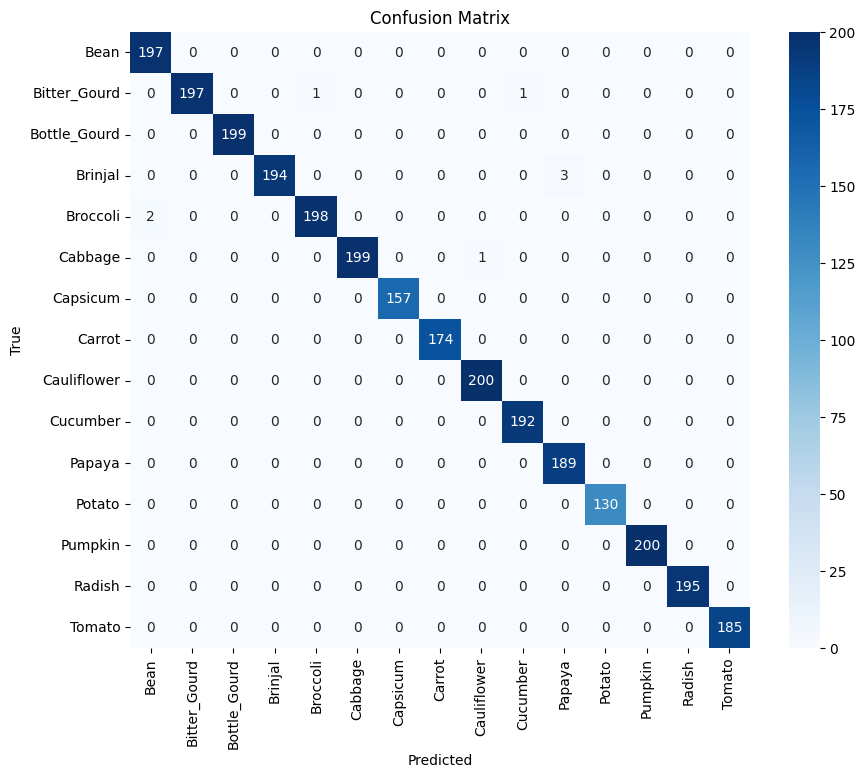

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Plot Training and Validation Loss and Accuracy
def plot_training_history(history):
    """
    Plot training and validation loss and accuracy.
    """
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()
    
def evaluate_model(model, test_ds):
    """
    Evaluate the model using a test dataset (tf.data.Dataset).
    """
    # Extract true labels and predictions
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        # Get predictions
        predictions = model.predict(images)
        y_pred.extend(np.argmax(predictions, axis=1))
        
        # Get true labels
        y_true.extend(np.argmax(labels.numpy(), axis=1))  # If labels are one-hot encoded

    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Get class labels
    class_labels = ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 
                    'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 
                    'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
# Plot Training History
plot_training_history(history)

# Evaluate the Model on Test Data
evaluate_model(model, test_ds)

# **Testing with imge**# 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Class: Tomato
Predicted Class: Tomato
Confidence: 99.34%


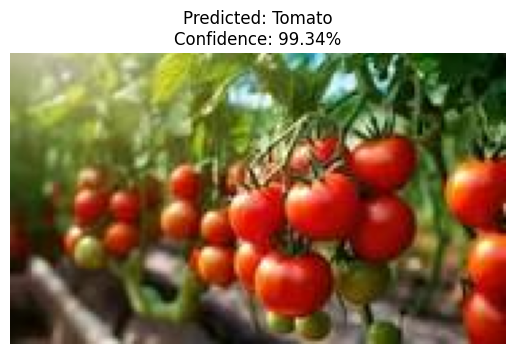

In [31]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# Load and preprocess the image
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))  # Resize to model input size
    img_array = image.img_to_array(img)  # Convert to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize (same as training)
    return img_array

# Predict the class of an image
def predict_image(model, img_path):
    class_labels = ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 
           'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 
           'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
    img_array = preprocess_image(img_path)
    prediction = model.predict(img_array)  # Get model prediction
    predicted_class = np.argmax(prediction)  # Get index of highest probability
    predicted_label = class_labels[predicted_class]  # Get class name
    
    print(f"Predicted Class: {predicted_label}")
    
# Confidence value (probability of the predicted class)
    confidence = np.max(prediction) * 100  # Convert to percentage
    
    print(f"Predicted Class: {predicted_label}")
    print(f"Confidence: {confidence:.2f}%")
    
    return predicted_label, confidence

def display_image(img_path, predicted_class, confidence):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR (OpenCV) to RGB
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

# Test the function
test_img_path = "/kaggle/input/testing/tomatoimg2.jpeg"  # Replace with the actual image path
predicted_class, confidence = predict_image(model, test_img_path)
display_image(test_img_path, predicted_class, confidence)


In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load your pre-trained model (assuming it's already saved)
model = load_model("/kaggle/working/Image_calssify.keras")  # Replace with your model path

# Define class labels
class_labels = ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 
                'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 
                'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']

# Function to preprocess the image
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))  # Resize to match model input size
    img = img / 255.0  # Normalize pixel values
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Function to predict the class of an image
def predict_image(model, img_path):
    img_array = preprocess_image(img_path)
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)  # Index of highest probability
    predicted_label = class_labels[predicted_class]  # Class name
    confidence = np.max(prediction) * 100  # Confidence percentage
    return predicted_label, confidence

# Function to test all images in a folder
def test_model_on_folder(model, folder_path):
    # Get list of image files in the folder
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print("No images found in the folder.")
        return
    
    # Iterate through each image and make predictions
    for image_file in image_files:
        img_path = os.path.join(folder_path, image_file)
        predicted_label, confidence = predict_image(model, img_path)
        
        # Display the image with prediction
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
        plt.imshow(img)
        plt.title(f"Predicted: {predicted_label}\nConfidence: {confidence:.2f}%")
        plt.axis("off")
        plt.show()
        
        # Print prediction details
        print(f"Image: {image_file}")
        print(f"Predicted Class: {predicted_label}")
        print(f"Confidence: {confidence:.2f}%")
        print("-" * 40)

# Path to the folder containing test images
test_folder_path = "/kaggle/input/vegetable-image-dataset/Vegetable Images/test/Capsicum"  # Replace with the actual folder path

# Test the model on the folder
test_model_on_folder(model, test_folder_path)

In [22]:
!pip install streamlit
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 63.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.7 MB/s eta 0:00:00:00:01
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 2s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼npm notice
npm notice New major version of npm available! 10.8.2 -> 11.1.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.1.0
npm notice To update run: npm install -g npm@11.1.0
npm notice
⠼

In [36]:
%%writefile app.py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
import streamlit as st
import numpy as np
from PIL import Image

# Load the .keras model
model = load_model('/kaggle/working/Image_calssify.keras')

data_cat = [
    ['Bean'], ['Bitter_Gourd'], ['Bottle_Gourd'], ['Brinjal'], ['Broccoli'], ['Cabbage'], ['Capsicum'], ['Carrot'], ['Cauliflower'], 
    ['Cucumber'], ['Papaya'], ['Potato'], ['Pumpkin'], ['Radish'], ['Tomato']
]

img_height = 224
img_width = 224

st.set_page_config(page_title="Fruit & Vegetable Classifier", layout="centered")
st.sidebar.title("About the Model")
st.sidebar.markdown(
    """
    - **Type**: Image Classification
    - **Model**: Convolutional Neural Network (CNN)
    - **Framework**: TensorFlow/Keras
    - **Classes**: 15 Categories
    """
)

st.title("🌟 Fruit & Vegetable Classifier 🌟")
st.write("Upload an image of a fruit or vegetable, and this app will classify it for you!")

uploaded_file = st.file_uploader("Choose an image", type=["jpg", "jpeg", "png"])

if uploaded_file:
    try:
        # Open the uploaded image using PIL
        image = Image.open(uploaded_file)
        # Resize the image to 224x224
        image = image.resize((img_width, img_height))
        # Convert the image to a numpy array
        img_arr = np.array(image)
        # Normalize the image
        img_arr = img_arr / 255.0
        # Add batch dimension
        img_bat = np.expand_dims(img_arr, axis=0)

        predict = model.predict(img_bat)
        score = tf.nn.softmax(predict)
        # Confidence value (probability of the predicted class)
        confidence = np.max(predict) * 100  # Convert to percentage
        print(confidence)

        st.image(image, width=250, caption="Uploaded Image")
        
        st.markdown(f"### Predicted Category: **{data_cat[np.argmax(score)][0]}**")
        #st.progress(int(np.max(score) * 100)) 
        st.markdown(f"### 🎯 confidence: **{confidence:.2f}%**")
    
    except Exception as e:
        st.error("An error occurred while processing the image. Please try a different file.")
else:
    st.info("👆 Upload an image file to get started!")

Overwriting app.py


In [24]:
# Your public ip is the password to the localtunnel
!curl ipv4.icanhazip.com

34.72.83.148


In [37]:
!streamlit run app.py &>./logs.txt & npx localtunnel --port 8501

⠙your url is: https://forty-maps-hammer.loca.lt
^C
